<a href="https://colab.research.google.com/github/Vaishakh252/NETFLIX_cases_study/blob/main/NETFLIX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NETFLIX CASE STUDY


**Q. Defining Problem Statement and Analysing basic metrics**

A. Here, we have data of multimedia streaming company "Netflix".


*   Earliest entry date: 1st JAN 2008 obtained by df['Date_added'].min()
*   Latest entry date: 25th SEP 2021 obtained by df['Date_added'].max()
*   Identifier - A Movie or TV Show: obtained by df['type'].value_counts()
                Movie      6131
                TV Show    2676

*   Country producing maximum number movies is United States









**Q. Observations on the shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required), missing value detection, statistical summary**

A.

1.   Shape of dataframe is (8807, 12) obtained by df.shape
2.   Datatype of all the attributes are of **object** type except for **'release year'**: obtained by df.dtypes
3.   Type column can be divided into category of "Movies" and "TV shows"
4.   In categorial column we will use mode method to fill NaN value, and in continuous column we will use mean method to fill NaN value.






**Q. Non-Graphical Analysis: Value counts and unique attributes**

A.

We can do Non graphical analysis using value_counts and unique attributes


1.   Rajiv Chilaka has directed the most number of movie
2.   Anupam Kher has acted in most number of movies
3.   United states has produced most number of movies
4.   Year 2019 has produced highest amount of movies









In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("netflix.csv")
df['director'].fillna(value='Unknown director', inplace=True)
nd= df['director'].apply(lambda x: x.split(',')).tolist()

df['cast'].fillna(value='Unknown Actor', inplace=True)
nca= df['cast'].apply(lambda x: x.split(',')).tolist()

df['country'].fillna(value='Unknown country', inplace=True)
nco= df['country'].apply(lambda x: x.split(',')).tolist()


In [ ]:
ndd = pd.DataFrame(nd,df['title']).stack().reset_index().drop(columns = 'level_1').rename(columns = {0:'director_name'})
ncaa = pd.DataFrame(nca,df['title']).stack().reset_index().drop(columns = 'level_1').rename(columns = {0:'cast'})
ncoo = pd.DataFrame(nco,df['title']).stack().reset_index().drop(columns = 'level_1').rename(columns = {0:'country'})


In [ ]:
merge_df = pd.merge(ndd, ncaa, on='title', how='outer')
seperated_df = pd.merge(merge_df, ncoo, on='title', how='outer')
new_df=pd.merge(seperated_df,df, on='title', how='outer')

new_df['duration'].fillna(value='0', inplace=True)
new_df['Date_added'] = pd.to_datetime(new_df['date_added'],format='mixed',dayfirst=True)
new_df['year_added'] = new_df['Date_added'].dt.year
new_df['month_added'] = new_df['Date_added'].dt.month
new_df.drop(columns=['cast_y', 'country_y','director'], inplace=True)
new_df.rename(columns = {'cast_x':'cast','country_x':'country'}, inplace=True)
new_df['Movie_Mins'] = new_df[new_df['type'] == 'Movie']['duration'].apply(lambda x: int(x.split(" ")[0]) if x else None)
new_df['Movie_Mins'].fillna(value='0', inplace=True)
new_df['Number of Seasons'] = new_df[new_df['type'] == 'TV Show']['duration'].apply(lambda x: int(x.split(" ")[0]) if x else None)
new_df['Number of Seasons'].fillna(value='0', inplace=True)

In [ ]:
new_df.head()

,title,director_name,cast,country,show_id,type,date_added,release_year,rating,duration,listed_in,description,Date_added,year_added,month_added,Movie_Mins,Number of Seasons
0,Dick Johnson Is Dead,Kirsten Johnson,Unknown Actor,United States,s1,Movie,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021-09-25,2021.0,9.0,90.0,0
1,Blood & Water,Unknown director,Ama Qamata,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021-09-24,2021.0,9.0,0,2.0
2,Blood & Water,Unknown director,Khosi Ngema,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021-09-24,2021.0,9.0,0,2.0
3,Blood & Water,Unknown director,Gail Mabalane,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021-09-24,2021.0,9.0,0,2.0
4,Blood & Water,Unknown director,Thabang Molaba,South Africa,s2,TV Show,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021-09-24,2021.0,9.0,0,2.0


In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'],format='mixed',dayfirst=True)
df['year_added'] = df['date_added'].dt.year
df['year_added'].fillna(value='0', inplace=True)
df['year_added'] = df['year_added'].apply(lambda x: int(x))
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown Actor,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021
1,s2,TV Show,Blood & Water,Unknown director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown country,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021
3,s4,TV Show,Jailbirds New Orleans,Unknown director,Unknown Actor,Unknown country,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021
4,s5,TV Show,Kota Factory,Unknown director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021


**Q.4. Graphical Analysis: Visual analysis**

A.4.

We can do graphical analysis using categorical and continuous values

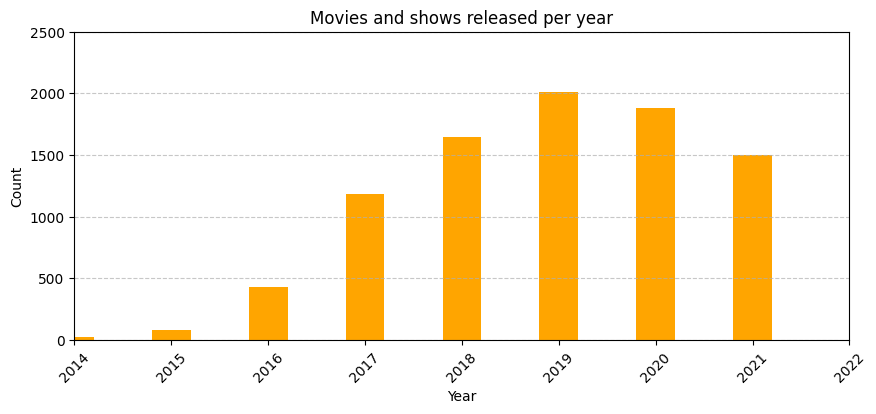

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'],format='mixed',dayfirst=True)
df['year_added'] = df['date_added'].dt.year
df['year_added'].fillna(value='0', inplace=True)
df['year_added'] = df['year_added'].apply(lambda x: int(x))

mpy = df.groupby('year_added')['title'].nunique()
ampy = pd.DataFrame(mpy).reset_index()
plt.figure(figsize=(10,4))
plt.title('Movies and shows released per year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xlim(left=2014,right=2022)
plt.ylim(bottom=0,top=2500)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.bar(x=ampy['year_added'], height=ampy['title'], width=0.4, color='orange')# graph between unique titles released each year
plt.show()


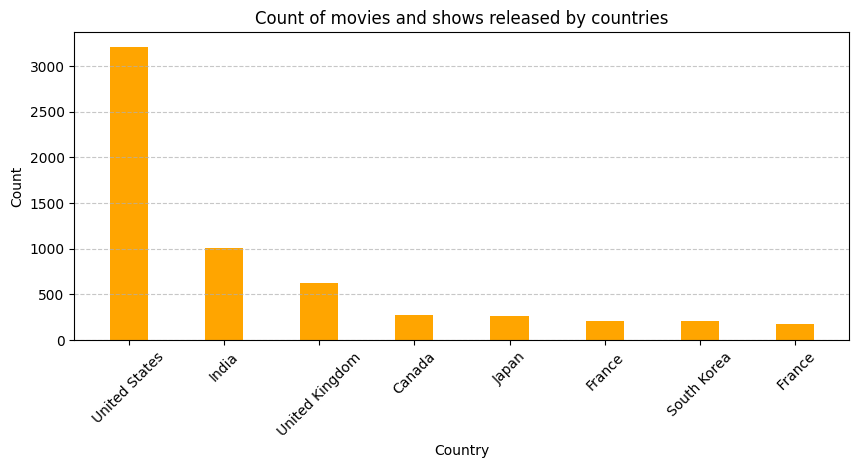

In [ ]:
mpc = new_df.groupby('country')['title'].nunique()
ampc = pd.DataFrame(mpc).reset_index()
ampc = ampc.nlargest(10, 'title')
ampc.drop([106,192], inplace=True)
# ampc
plt.figure(figsize=(10,4))
plt.title('Count of movies and shows released by countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.bar(x=ampc['country'], height=ampc['title'], width=0.4, color='orange')# graph between unique countries vs movies and shows released by them
plt.show()

In [ ]:
### new from hints

Comparison of tv shows vs. movies.

number of movies produced in each country (pick the top 10 countries.)

---



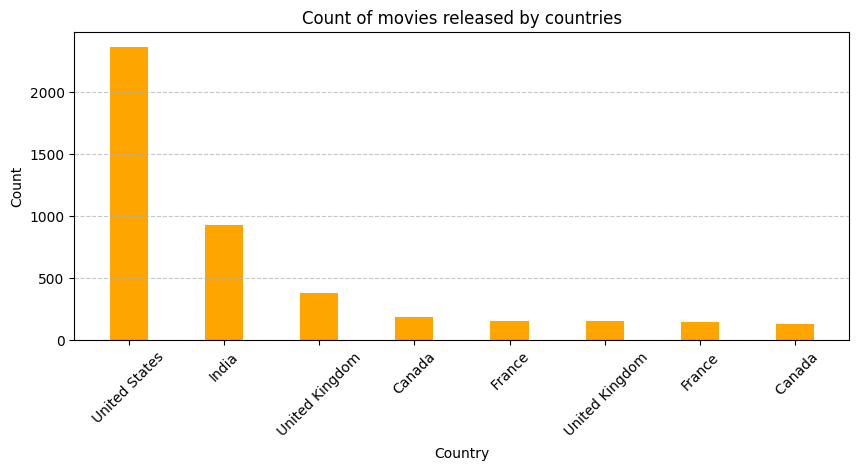

In [ ]:
movie_values = new_df[new_df['type'] == 'Movie']
nmpc = movie_values.groupby('country')['title'].nunique()
nmpc = pd.DataFrame(nmpc).reset_index()
nmpc = nmpc.nlargest(10,'title')
nmpc.drop([103,182], inplace=True)
# nmpc #no. of movies per country
plt.figure(figsize=(10,4))
plt.title('Count of movies released by countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.bar(x=nmpc['country'], height=nmpc['title'], width=0.4, color='orange')# graph between unique countries vs movies released by them
plt.show()

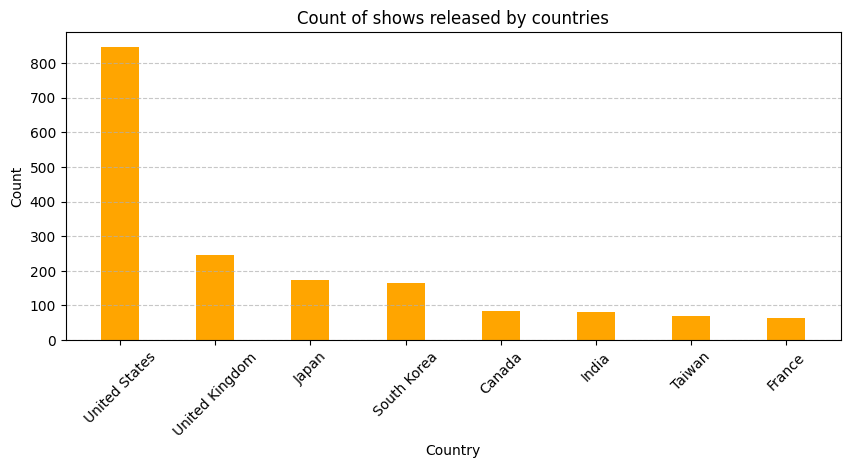

In [ ]:
show_values = new_df[new_df['type'] == 'TV Show']
nspc = show_values.groupby('country')['title'].nunique()
nspc = pd.DataFrame(nspc).reset_index()
nspc = nspc.nlargest(10,'title')
nspc.drop([101,42], inplace=True)
# nspc #no. of shows per country
plt.figure(figsize=(10,4))
plt.title('Count of shows released by countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.bar(x=nspc['country'], height=nspc['title'], width=0.4, color='orange')# graph between unique countries vs movies released by them
plt.show()

**Q. Which month is best for releasing TV shows and movies**

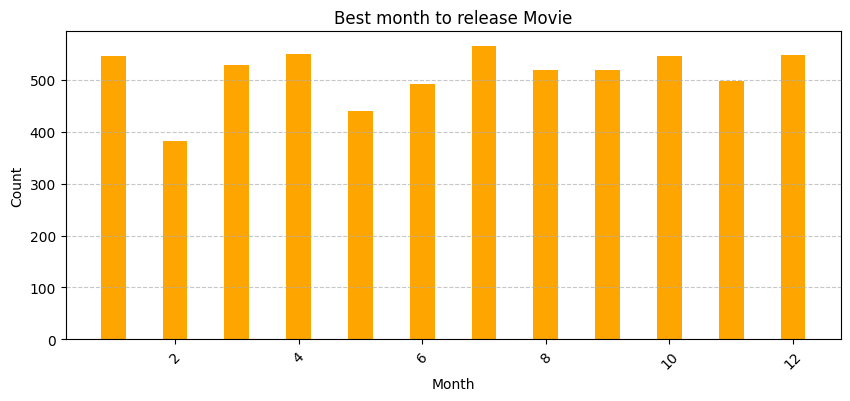

In [ ]:
movie_values = new_df[new_df['type'] == 'Movie']
bmrm = movie_values.groupby('month_added')['title'].nunique()
bmrm = pd.DataFrame(bmrm).reset_index()
bmrm = bmrm.nsmallest(13,'month_added')
bmrm #best month to release Movie
plt.figure(figsize=(10,4))
plt.title('Best month to release Movie')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.bar(x=bmrm['month_added'], height=bmrm['title'], width=0.4, color='orange')# graph between unique countries vs movies released by them
plt.show()

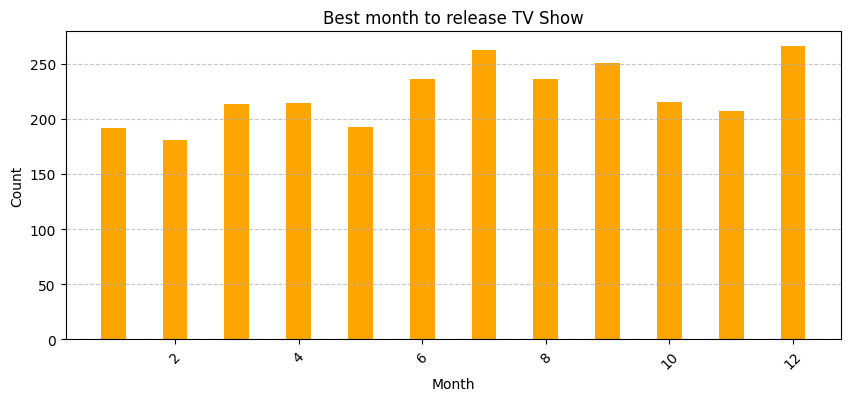

In [ ]:
show_values = new_df[new_df['type'] == 'TV Show']
bmrs = show_values.groupby('month_added')['title'].nunique()
bmrs = pd.DataFrame(bmrs).reset_index()
bmrs = bmrs.nsmallest(13,'month_added')
bmrs #best month to release TV Show
plt.figure(figsize=(10,4))
plt.title('Best month to release TV Show')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.bar(x=bmrs['month_added'], height=bmrs['title'], width=0.4, color='orange')# bestmonth to release tv show
plt.show()

**Q. Analysis of actors/directors of different types of shows or movies.**

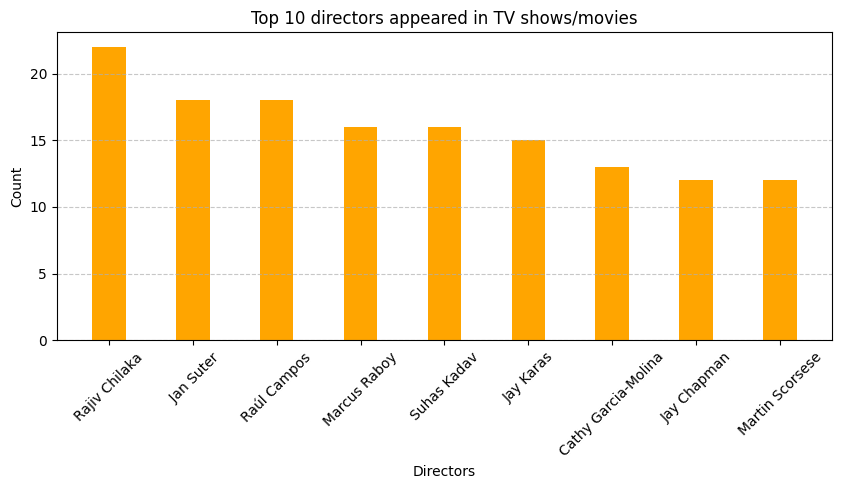

In [ ]:
adasm = new_df.groupby('director_name')['title'].nunique()
adasm = pd.DataFrame(adasm).reset_index()
adasm = adasm.nlargest(10, 'title')
adasm=adasm[1:] #analysis of directors appeared in shows and movies
plt.figure(figsize=(10,4))
plt.title('Top 10 directors appeared in TV shows/movies')
plt.xlabel('Directors')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.bar(x=adasm['director_name'], height=adasm['title'], width=0.4, color='orange')# Top 10 directors
plt.show()


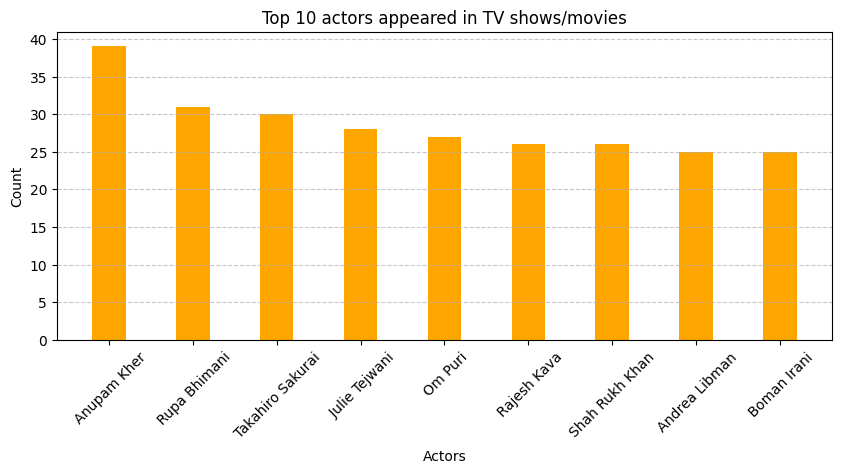

In [ ]:
aaasm = new_df.groupby('cast')['title'].nunique()
aaasm = pd.DataFrame(aaasm).reset_index()
aaasm = aaasm.nlargest(10, 'title')
aaasm=aaasm[1:] #analysis of actors appeared in shows and movies
plt.figure(figsize=(10,4))
plt.title('Top 10 actors appeared in TV shows/movies')
plt.xlabel('Actors')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.bar(x=aaasm['cast'], height=aaasm['title'], width=0.4, color='orange')# graph between unique countries vs movies and shows released by them
plt.show()


**BUSINESS INSIGHTS**

From the graph "Movies and shows released per year", we can conclude that


*   In the year 2019 most number of movies and TV shows were released
*   Before 2017, the release of movies/Tv shows in netflix were very less. But after 2017, there was huge growth in the release of movies/TV.
*   After 2019, the multimedia released per year dropped mostly due to rising COVID cases.



From the graph 'Count of movies and shows released by countries', we can conclude that


*   United states produces most number multimedia, followed by India, UK
*   There is a huge gap between the count of media released by US and India.


From the graph 'Count of movies released by countries', we can conclude that


*   United states produces most number movies, followed by India, UK
*   There is a huge gap between the count of movies released by US and India.


From the graph 'Count of TV shows released by countries', we can conclude that


*   United states produces most number TV shows, followed by UK, Japan
*   There is a huge gap between the count of movies released by US and UK.


From the graph 'best month to release Movie', we can conclude that


*   July is the best month to release Movies. However, we can see that in almost all months except for Feb, May and June had count of movies released above 500.
*   February had the least number of movie released.


From the graph 'best month to release TV Show', we can conclude that


*   December and July are the best month to release Movies.
*   January, February and May had the least number of movie released (i.e. below 200).


From the graph 'Top 10 directors appeared in TV shows/movies', we can conclude that


*   Rajiv Chilaka, Jan Suter, Raul Campos, Marcus Raboy, Suhas Kadav, Jay Karas, Cathy Garcia-Molina, Jay Champman and Martin Scorsese are the top 10 directors who directed Movies/TV shows.


From the graph 'Top 10 actors appeared in TV shows/movies', we can conclude that


*   Anupam Kher, Rupa Bhimani, Takahiro Sakurai, Julie Tejwani, Om puri, Rajesh Kava, Shah Rukh Khan, Andrea Libman, Boman Irani are the top 10 actors who were casted in Movies/TV shows.
*   We can also conclude that, most of the top 10 actors are of Indian origin.






**RECOMMENDATIONS**


*   Amount of movies released in India is comparitively high compared to other countries except for US. However, India lacks in production of TV shows. Hence, Netflix India should focus more on onboarding more Indian shows.